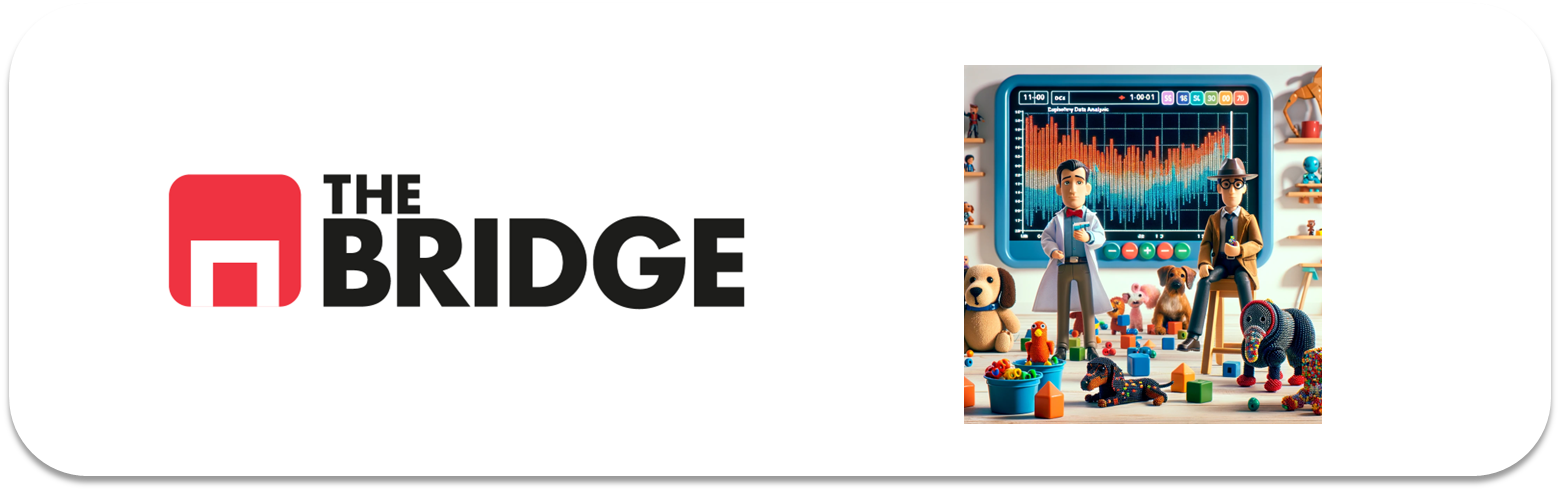

## PRACTICA OBLIGATORIA: ANÁLISIS MULTIVARIANTE

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import pandas as pd
import seaborn as sns
from bootcampviztools import plot_categorical_relationship_fin, pinta_distribucion_categoricas, plot_grouped_histograms,\
    plot_grouped_boxplots, plot_combined_graphs, plot_categorical_numerical_relationship, bubble_plot,\
        grafico_dispersion_con_correlacion
from scipy.stats import chi2_contingency, mannwhitneyu

## #1 TITANIC

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [3]:
df_titanic = pd.read_csv("../data/titanic.csv")

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [4]:
df_titanic.drop(["deck", "survived", "pclass", "embarked"], axis=1, inplace=True)
df_titanic

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [5]:
df_titanic["family_members"] = df_titanic["parch"] + df_titanic["sibsp"]
df_titanic

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True,0


In [6]:
df_titanic.drop(["parch", "sibsp"], axis=1, inplace=True)
df_titanic

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [7]:
df_titanic["embark_town"] = df_titanic["embark_town"].fillna(df_titanic["embark_town"].mode()[0])
df_titanic["embark_town"].isnull().value_counts()

embark_town
False    891
Name: count, dtype: int64

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [18]:
woman = df_titanic["who"] == "woman"
child = df_titanic["who"] == "child"
man = df_titanic["who"] == "man"

media_woman = df_titanic.loc[woman, "age"].mean()
print(f"La media de edad de las mujeres es {media_woman}")

media_child = round(df_titanic.loc[child, "age"].mean(), 2)
print(f"La media de edad de los niños es {media_child}")

media_man = round(df_titanic.loc[man, "age"].mean(), 2)
print(f"La media de edad de los hombres es de {media_man}")

age_nulo = df_titanic["age"].isna()

df_titanic.loc[woman & age_nulo, "age"] = media_woman
df_titanic.loc[child & age_nulo, "age"] = media_child
df_titanic.loc[man & age_nulo, "age"] = media_man

La media de edad de las mujeres es 32.0
La media de edad de los niños es 6.37
La media de edad de los hombres es de 33.17


In [19]:
df_titanic["age"].isnull().value_counts()

age
False    891
Name: count, dtype: int64

In [20]:
df_titanic.head(15)

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.00,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.00,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.00,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.00,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.00,8.0500,Third,man,True,Southampton,no,True,0
5,male,33.17,8.4583,Third,man,True,Queenstown,no,True,0
6,male,54.00,51.8625,First,man,True,Southampton,no,True,0
7,male,2.00,21.0750,Third,child,False,Southampton,no,False,4
8,female,27.00,11.1333,Third,woman,False,Southampton,yes,False,2
9,female,14.00,30.0708,Second,child,False,Cherbourg,yes,False,1


### 1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

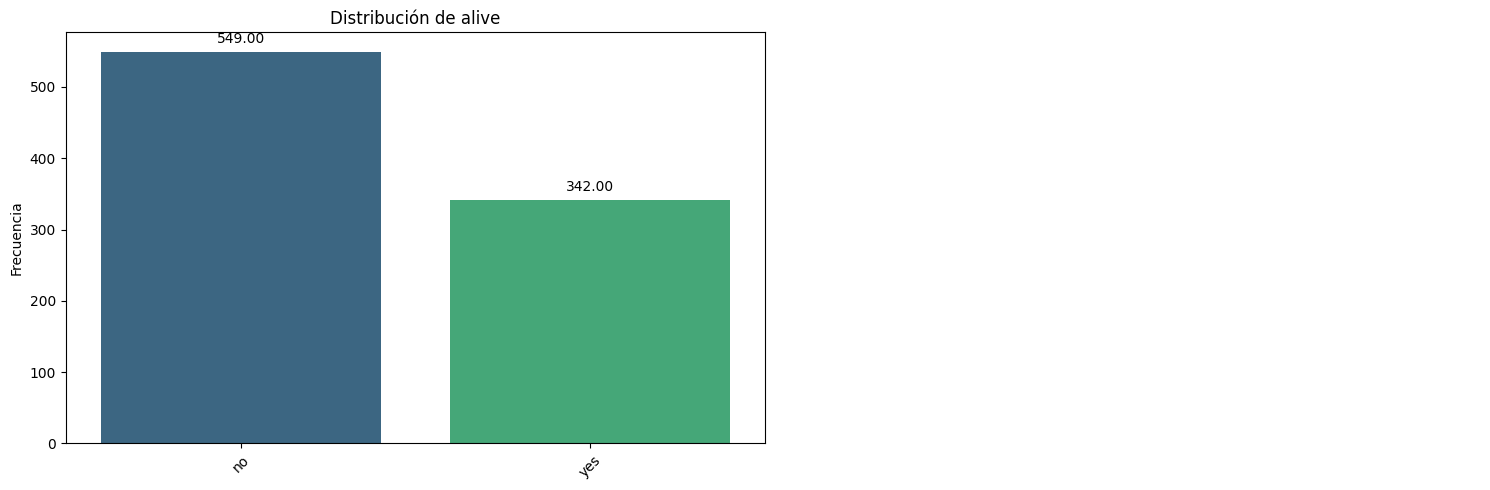

In [31]:
pinta_distribucion_categoricas(df_titanic, ["alive"], mostrar_valores=True)

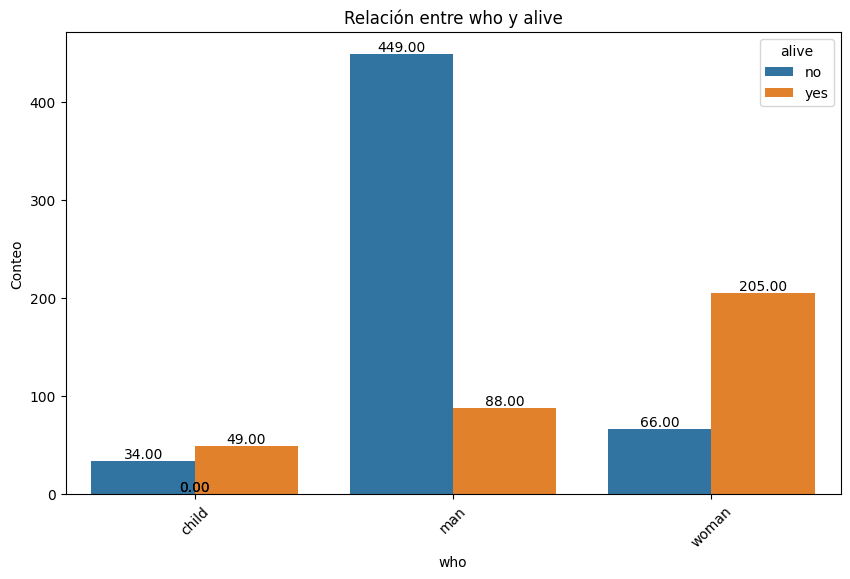

In [32]:
plot_categorical_relationship_fin(df_titanic, "who","alive", show_values=True)

En términos absolutos se aprecia que murieron muchos más hombres que mujeres y niños

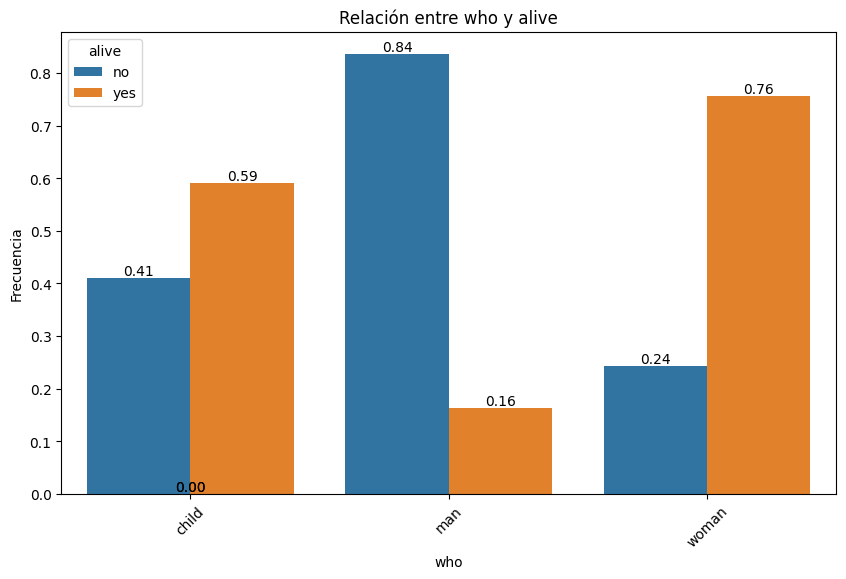

In [33]:
plot_categorical_relationship_fin(df_titanic, "who","alive",relative_freq=True, show_values=True)

En términos relativos se sigue apreciando que la mayoría de los hombres que viajaba a bordo del titanic fallecieron (84%) frente a un 41% de niños y un 24% de mujeres.

In [34]:
tabla_contingencia = pd.crosstab(df_titanic["alive"], df_titanic["who"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print(f"El valor de chi2 es {chi2}")
print(f"El p-valor es {p}")
print(f"Los grados de libertad son {dof}")
print(f"La tabla de frecuencias esperadas es: \n {expected}")

El valor de chi2 es 283.923050324233
El p-valor es 2.2227620817798914e-62
Los grados de libertad son 2
La tabla de frecuencias esperadas es: 
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


Debido al p-valor, podemos rechazar la hipotesis nula, por lo que la relacion entre el sexo/edad del viajero y su supervivencia es estadísticamente significativa

In [ ]:
# adultos = df_titanic["who"] == "woman" | "man"
# niños = df_titanic["who"] == "child"
df_titanic["grupo"] = df_titanic["who"].isin(["man", "woman"]) # Creo una nueva columna que clasifique segun adulto/ niño
df_titanic["grupo"] = df_titanic["grupo"].map({True: "adulto", False: "niño"})

tabla_contingencia2 = pd.crosstab(df_titanic["alive"], df_titanic["grupo"]) #Creo una nueva tabla de contingencia para aplicar chi2

chi2, p, dof, expected = chi2_contingency(tabla_contingencia2)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 15.556993340077092
P-Value: 8.005497211300105e-05
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[497.85858586  51.14141414]
 [310.14141414  31.85858586]]


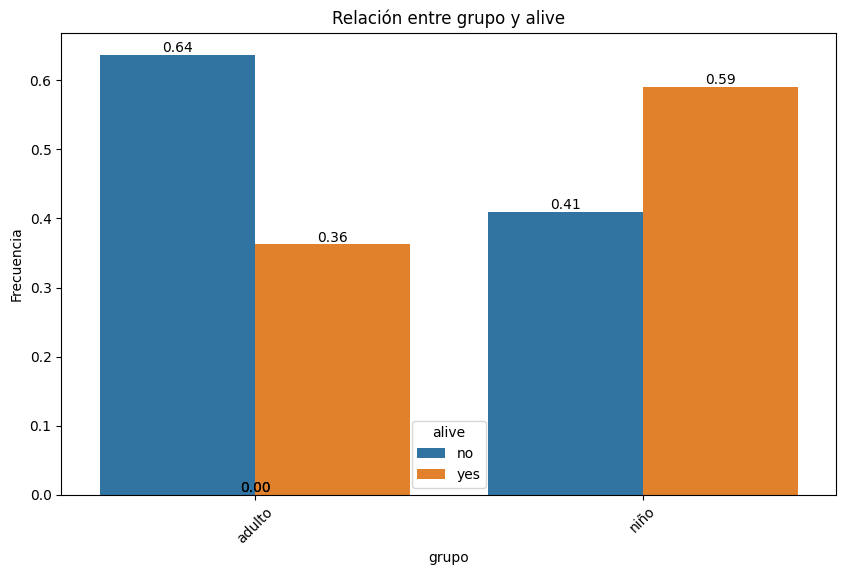

In [37]:
plot_categorical_relationship_fin(df_titanic, "grupo", "alive", relative_freq=True, show_values=True)

El p-valor nos dice que también hay relacion estadistica significativa entre ser adulto o niño y sobrevivir con una diferencia en la tasa de fallecimiento de un 23%

In [36]:
df_titanic.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,grupo
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1,adulto
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1,adulto
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0,adulto
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1,adulto
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0,adulto


2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

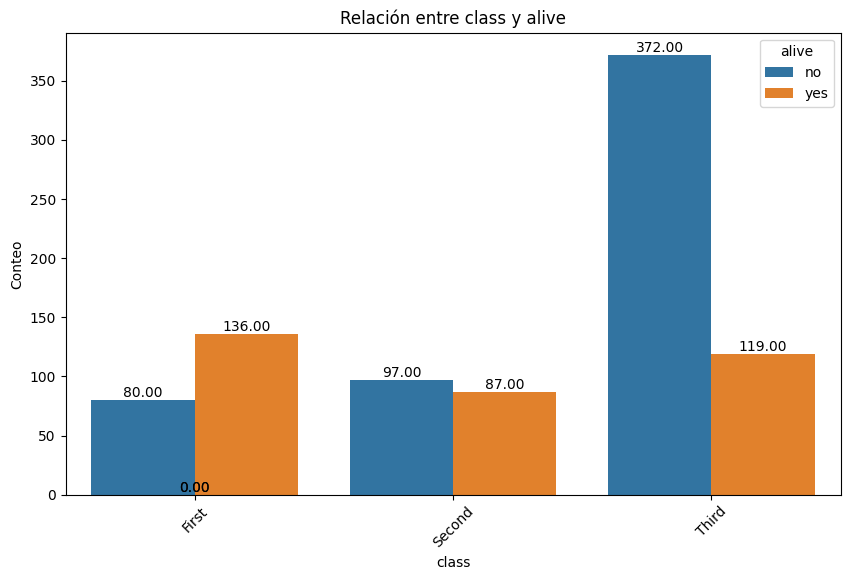

In [38]:
plot_categorical_relationship_fin(df_titanic, "class", "alive", show_values= True)

Se observa, que en terminos absolutos, sobrevivieron más pasajeros con billetes de primera que de segunda y tercera

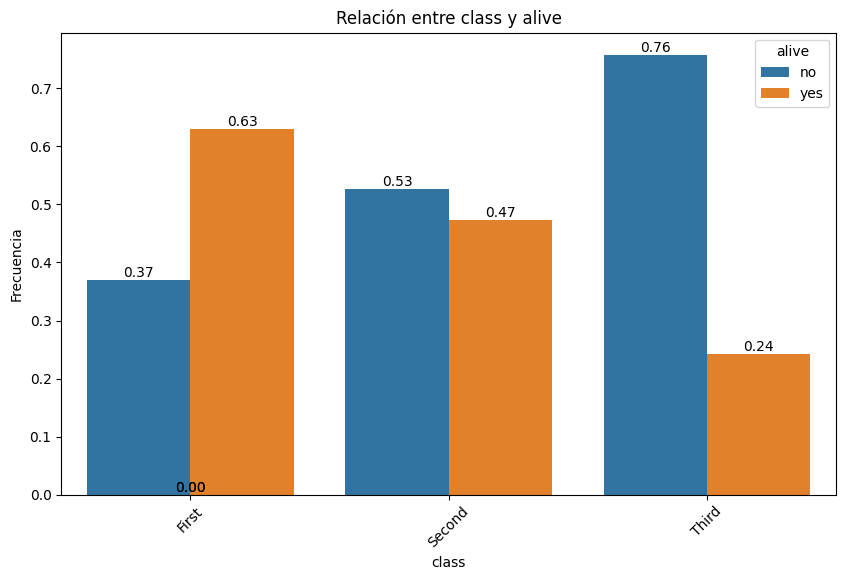

In [39]:
plot_categorical_relationship_fin(df_titanic, "class", "alive",relative_freq=True, show_values= True)

En términos relativos, se observa una mortalidad elevada (76%) en los pasajeros con billetes de tercera, la cual desciende hasta 53% en billetes de segunda y 37% en billetes de primera.

In [40]:
tabla_contingencia3 = pd.crosstab(df_titanic["alive"],df_titanic["class"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia3)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


Relación estadística significativa entre la clase del billete y la tasa de supervivencia dado el p-valor

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

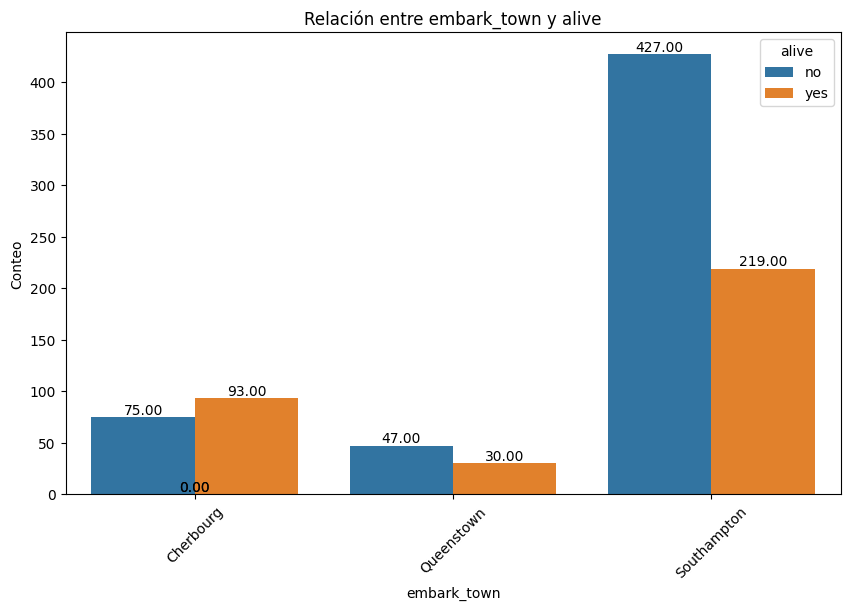

In [41]:
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive", show_values=True)

Se observa que los pasajeros que embarcaron desde Southampton fallecieron en mayor medida que los que embarcaron en otra ciudad.

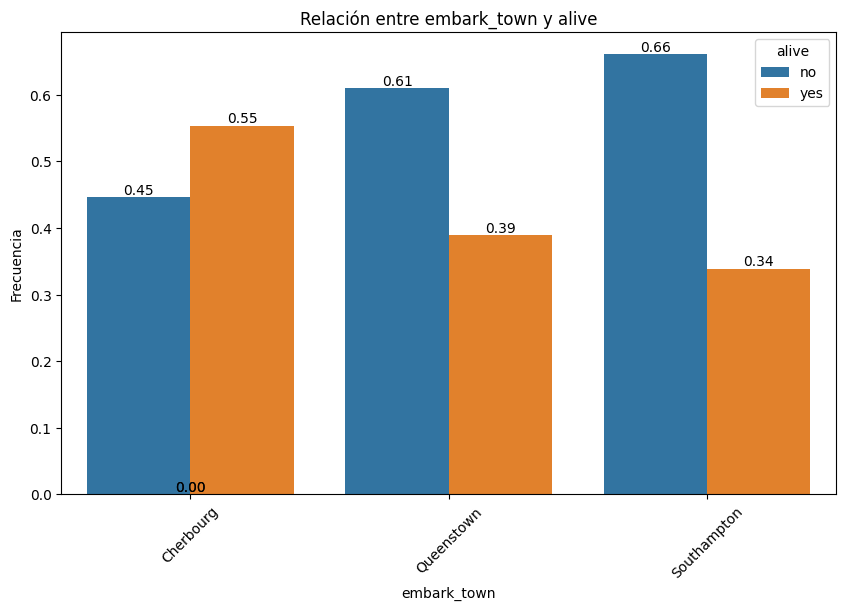

In [42]:
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive",relative_freq=True, show_values=True)

En términos relativos, se observa mayor tasa de supervivencia de las personas que embarcaron en Cherbourg frente a Queenstown o Southampton

In [43]:
tabla_contingencia4 = pd.crosstab(df_titanic["alive"],df_titanic["embark_town"])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia4)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]


Se demuestra relacion estadistica significativa entre la ciudad de embarque y la supervivencia del pasajero

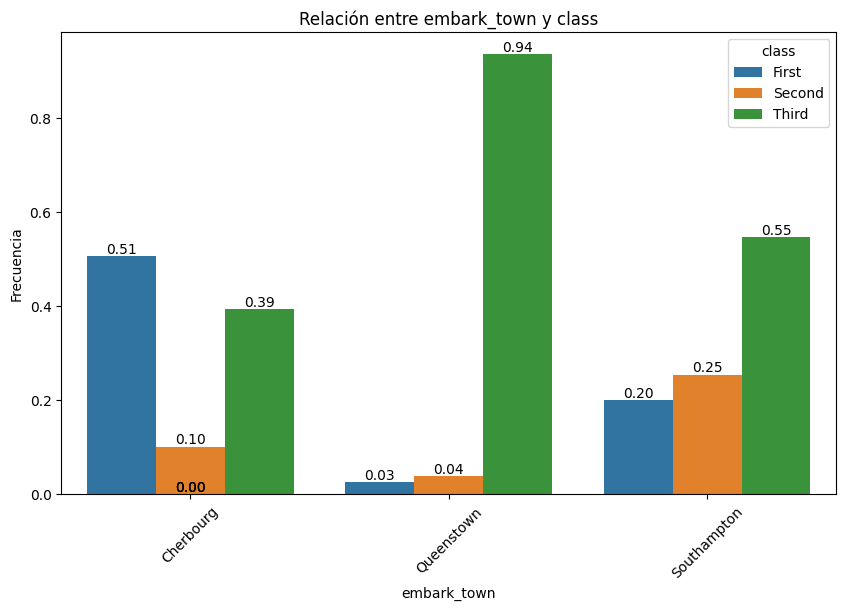

In [44]:
plot_categorical_relationship_fin(df_titanic, "embark_town", "class", relative_freq=True, show_values=True)

A pesar de ser el puerto donde embarcaron menos personas, Queenstown tiene la segunda tasa de mortalidad en pasajeros. Tras analizar la clase de los billetes, vemos en terminos relativos que un 94% de los billetes fueron de tercera clase en Queenstown, mientras que en Cherbourg predominaron los billetes de primera clase. Previamente hemos visto como la clase influia en la supervivencia del pasajero.

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

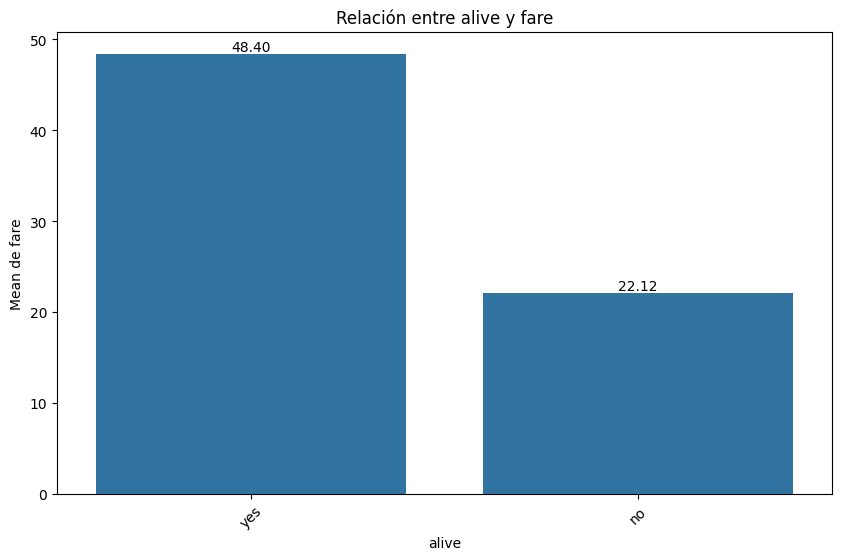

In [45]:
plot_categorical_numerical_relationship(df_titanic, "alive", "fare",show_values=True )

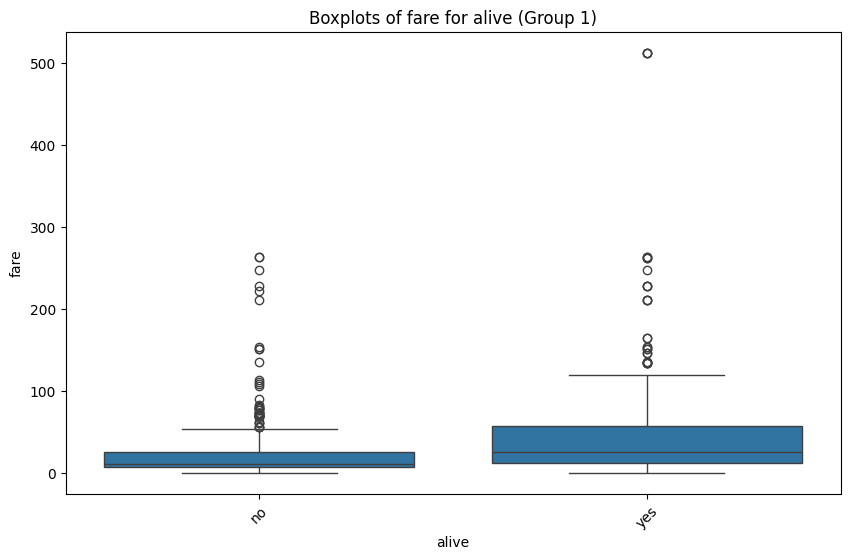

In [46]:
plot_grouped_boxplots(df_titanic, "alive", "fare")

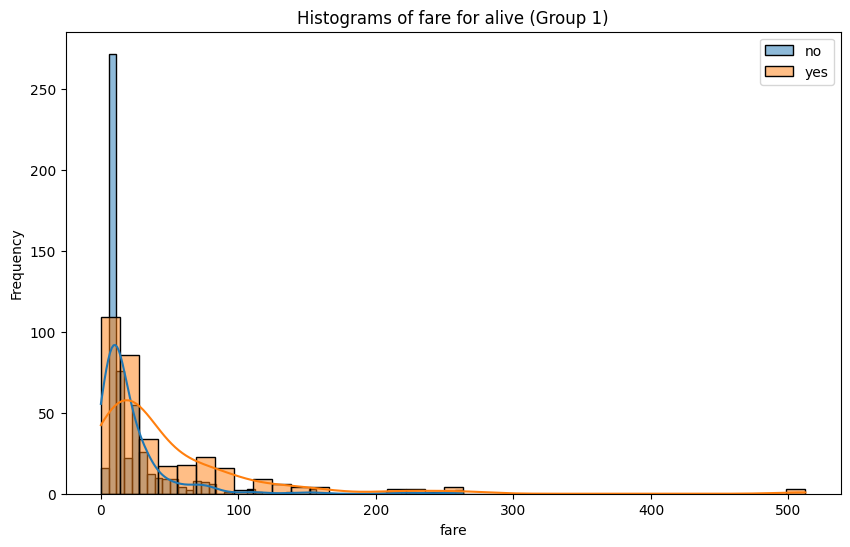

In [51]:
plot_grouped_histograms(df_titanic, "alive", "fare", group_size= 3)

In [59]:
grupo_a = df_titanic.loc[df_titanic.alive == "yes"]["fare"]
grupo_b = df_titanic.loc[df_titanic.alive == "no"]["fare"]

# print(grupo_a)
# print(grupo_b)

u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print(f"Estadístico U: {u_stat}")
print(f"P-valor = {p_valor}")

Estadístico U: 129951.5
P-valor = 4.553477179250237e-22


Dado el p-valor, podemos decir que hay relación estadistica significativa entre el precio del billete y la supervivencia

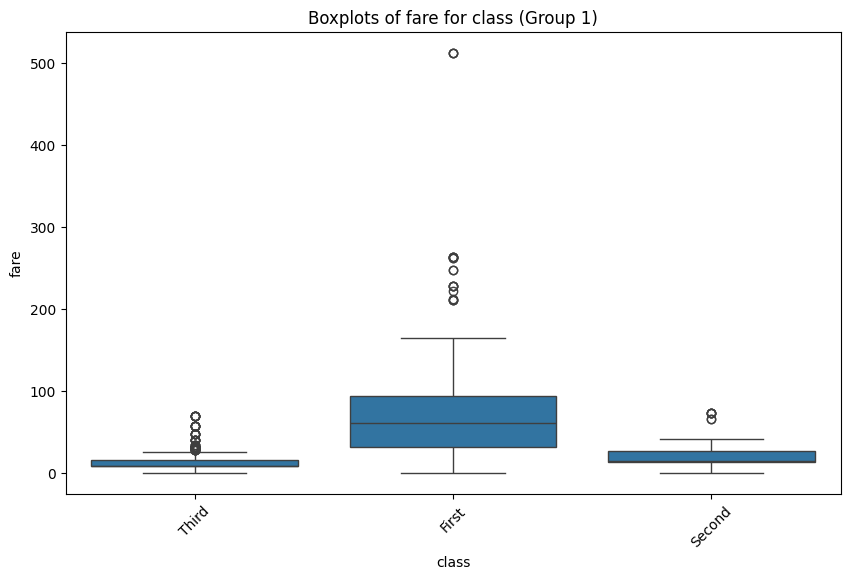

In [60]:
plot_grouped_boxplots(df_titanic, "class", "fare")

In [61]:
df_alive = df_titanic.loc[df_titanic.alive == "yes"].copy()
df_dead = df_titanic.loc[df_titanic.alive == "no"].copy()

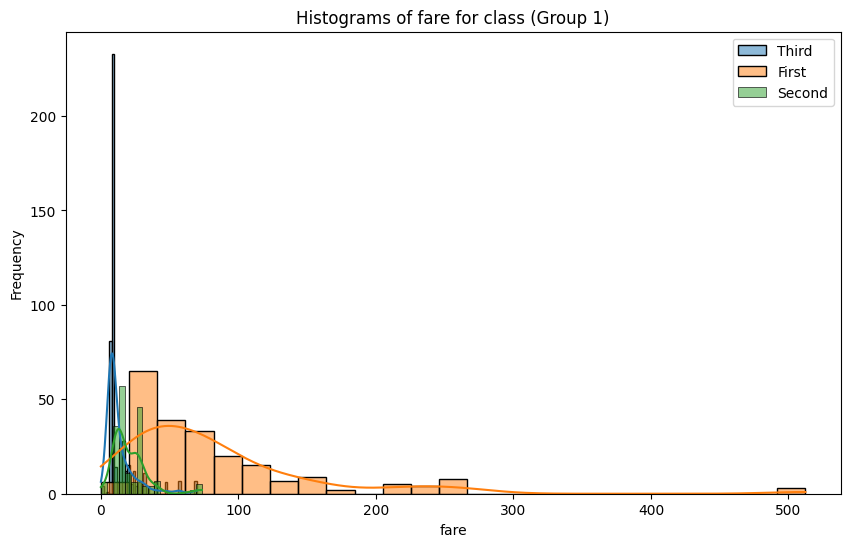

In [62]:
plot_grouped_histograms(df_titanic, "class", "fare", group_size=3)

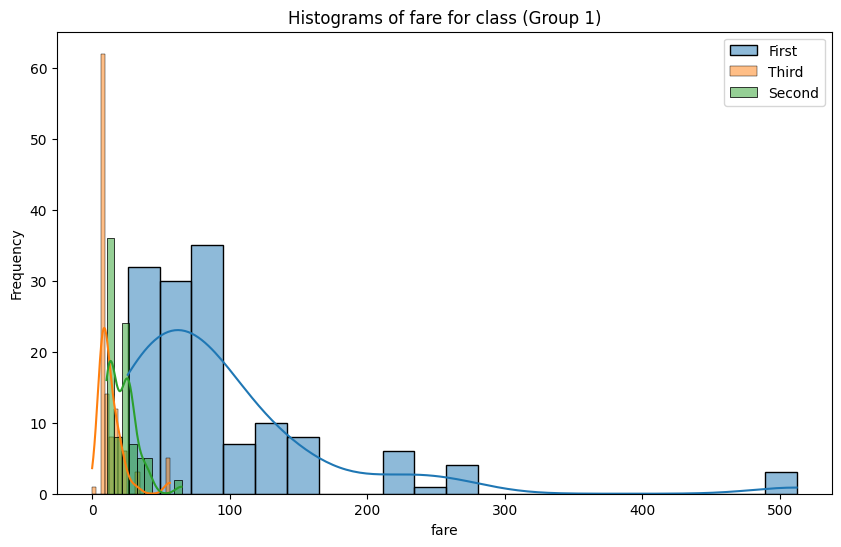

In [63]:
plot_grouped_histograms(df_alive, "class", "fare", group_size= 3)

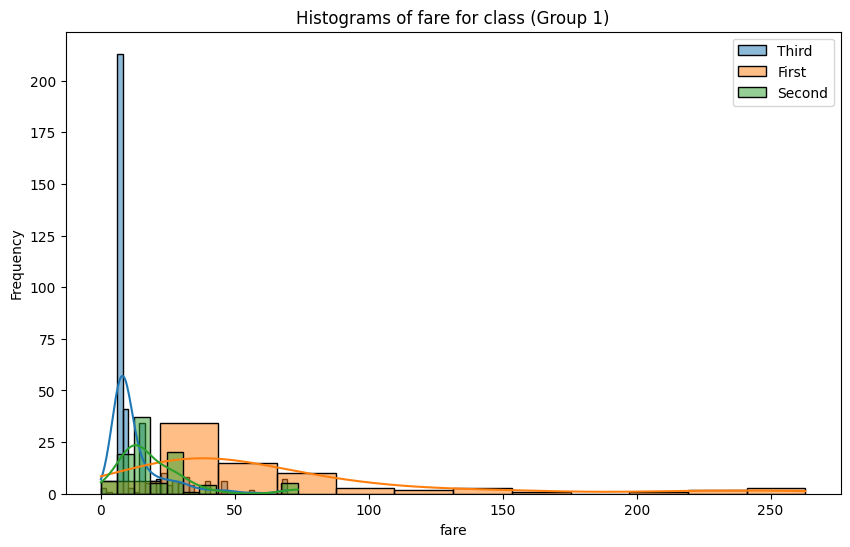

In [64]:
plot_grouped_histograms(df_dead, "class", "fare", group_size=3)

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

In [72]:
df_titanic.loc[df_titanic["fare"] == 0]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,grupo
179,male,36.00,0.0,Third,man,True,Southampton,no,True,0,adulto
263,male,40.00,0.0,First,man,True,Southampton,no,True,0,adulto
271,male,25.00,0.0,Third,man,True,Southampton,yes,True,0,adulto
277,male,33.17,0.0,Second,man,True,Southampton,no,True,0,adulto
302,male,19.00,0.0,Third,man,True,Southampton,no,True,0,adulto
413,male,33.17,0.0,Second,man,True,Southampton,no,True,0,adulto
466,male,33.17,0.0,Second,man,True,Southampton,no,True,0,adulto
481,male,33.17,0.0,Second,man,True,Southampton,no,True,0,adulto
597,male,49.00,0.0,Third,man,True,Southampton,no,True,0,adulto
633,male,33.17,0.0,First,man,True,Southampton,no,True,0,adulto


In [74]:
df_titanic.loc[df_titanic["fare"] == df_titanic.fare.max()]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,grupo
258,female,35.0,512.3292,First,woman,False,Cherbourg,yes,True,0,adulto
679,male,36.0,512.3292,First,man,True,Cherbourg,yes,False,1,adulto
737,male,35.0,512.3292,First,man,True,Cherbourg,yes,True,0,adulto


Las 3 personas que más dinero gastaron en el billete sobrevivieron e iban en primera clase (obvio).

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

In [75]:
def trivariant_analysis(df, directora, cat2, num1, group_size = 3, bins = "auto"):
    col_directora = directora
    col_1 = cat2
    col_2 = num1
    diccionario_multivariante = {}
    for valor in df[col_directora].unique():
        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 

    for valor,df_datos in diccionario_multivariante.items():
        print(f"Respuesta {valor}:")
        plot_grouped_histograms(df_datos,col_1,col_2, group_size= group_size)

Respuesta Southampton:


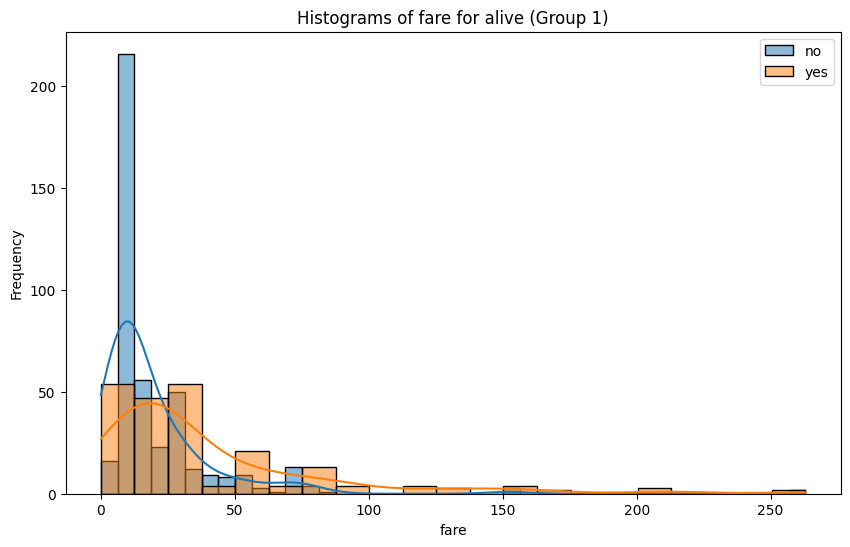

Respuesta Cherbourg:


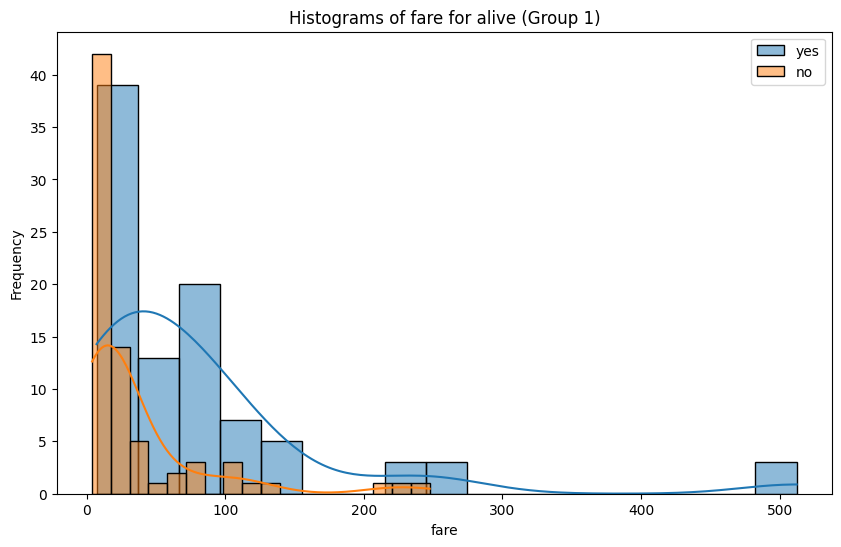

Respuesta Queenstown:


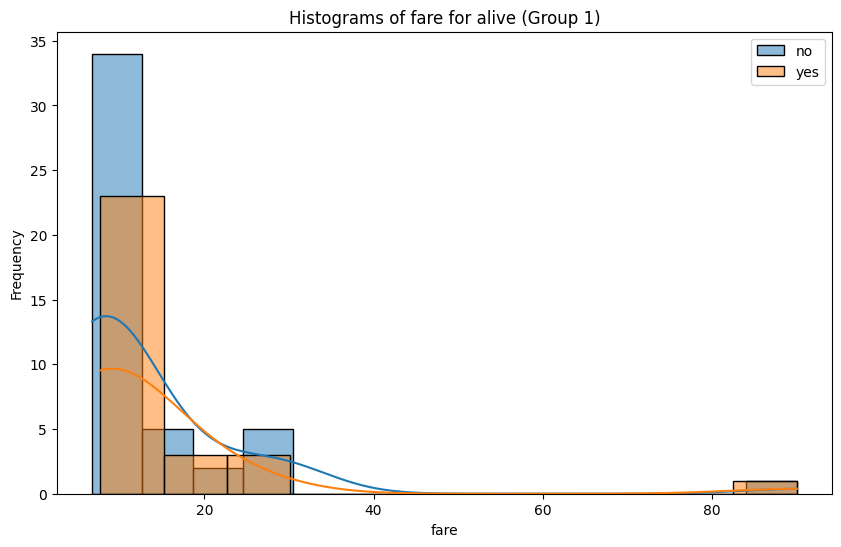

In [77]:
trivariant_analysis(df_titanic, "embark_town", "alive", "fare")

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

(2,)


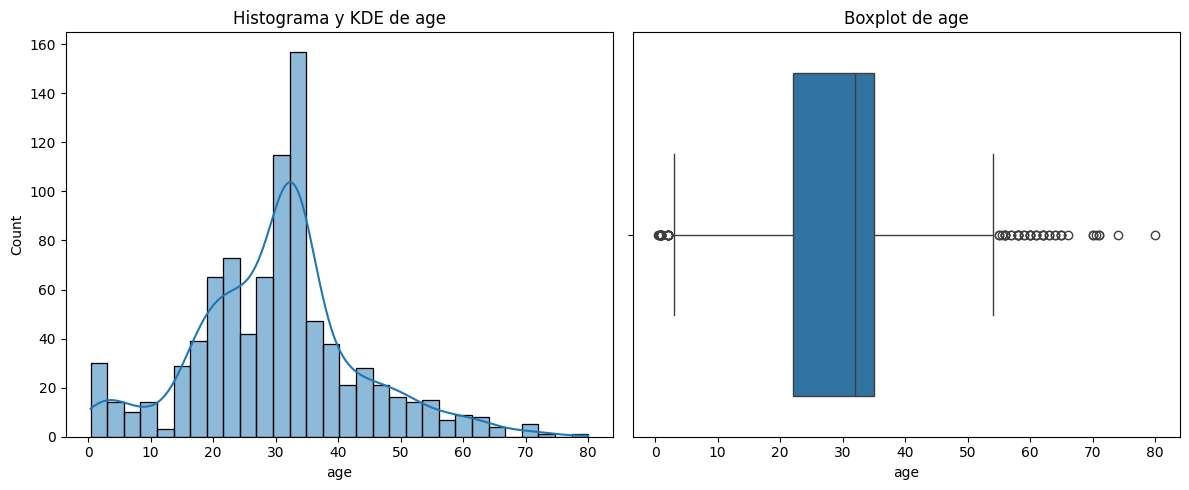

In [78]:
plot_combined_graphs(df_titanic, ["age"])

In [79]:
df_titanic["age"].describe()

count    891.000000
mean      30.319024
std       13.063744
min        0.420000
25%       22.000000
50%       32.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64

In [81]:
bins = [0, 22, 32, 35, 80]
df_titanic["cat_age"] = pd.cut(df_titanic.age, bins= bins, labels= ["age_1", "age_2", "age_3", "age_4"])
df_titanic.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,grupo,cat_age
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1,adulto,age_1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1,adulto,age_4
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0,adulto,age_2
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1,adulto,age_3
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0,adulto,age_3


In [82]:
def tricategorical_analysis(df, directora, otras, relativa = False, muestra_valores = False):
    col_directora = directora
    col_1 = otras[0]
    col_2 = otras[1]
    diccionario_multivariante = {}
    for valor in df[col_directora].unique():
        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 

    for valor,df_datos in diccionario_multivariante.items():
        print(f"Respuesta {valor}:")
        plot_categorical_relationship_fin(df_datos,col_2,col_1, relative_freq= relativa, show_values= muestra_valores)

Respuesta age_1:


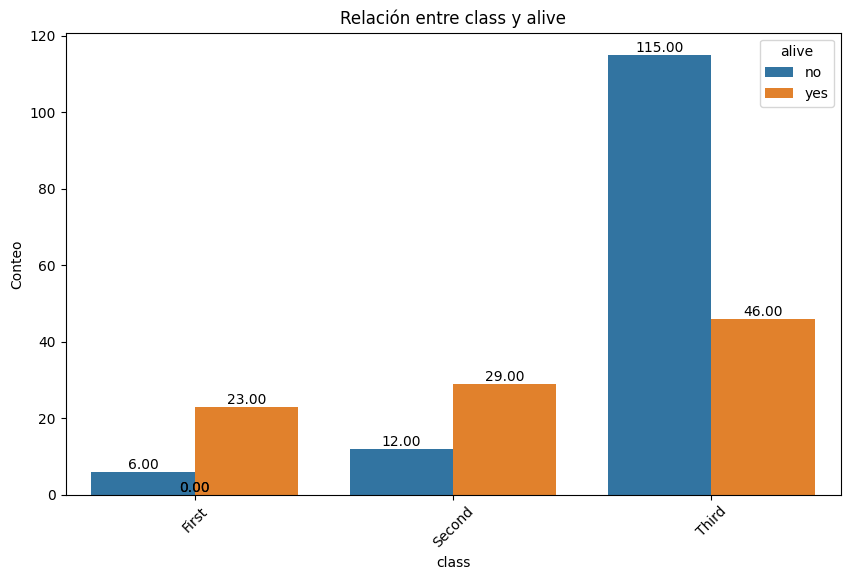

Respuesta age_4:


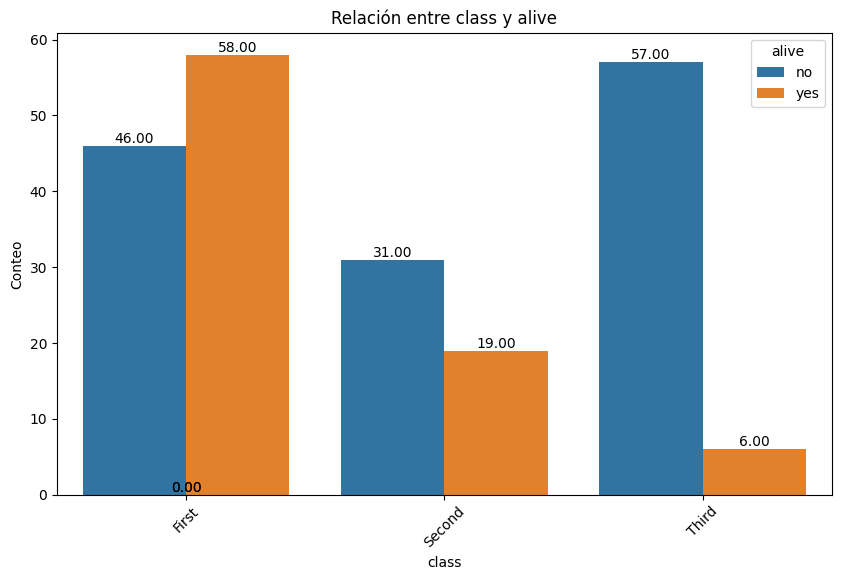

Respuesta age_2:


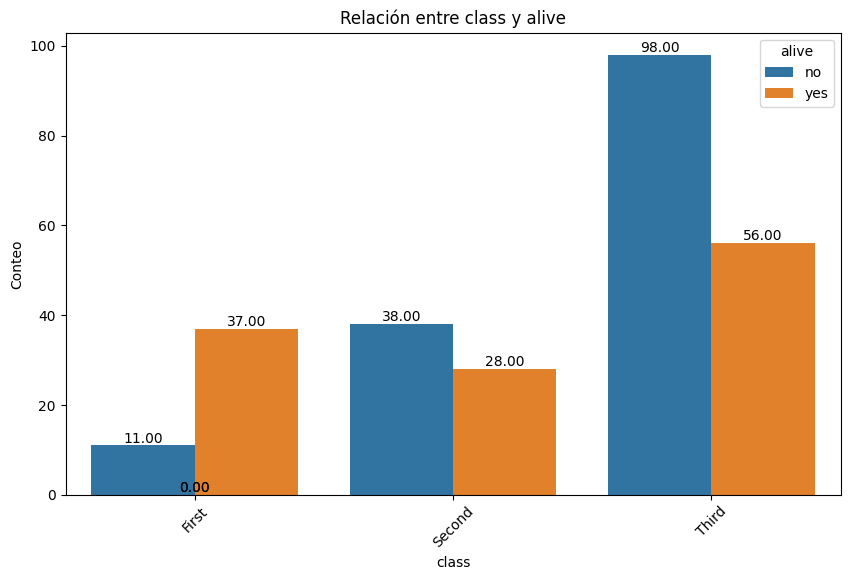

Respuesta age_3:


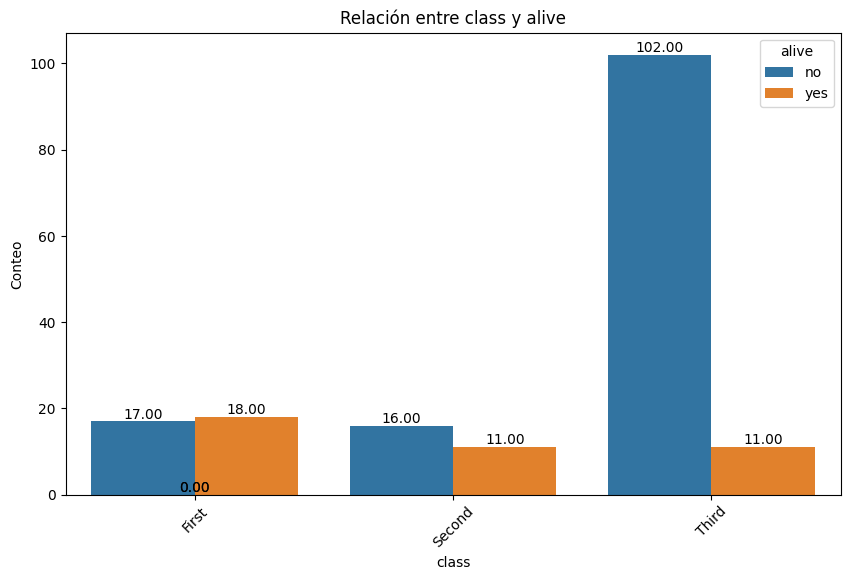

In [83]:
tricategorical_analysis(df= df_titanic, directora= "cat_age", otras= ["alive", "class"], muestra_valores= True)

En términos absolutos, se observa que, en el grupo age_4, los supervivientes de primera clase fueron más que en el resto de grupos.
En segunda clase, se observa como el grupo age_1 tiene un mayor conteo de supervivientes que el resto de grupos de edad.
Finalmente, comentar que para el grupo age_2, se aprecia diferencia en el conteo de supervivientes para la tercera clase, siendo está la más mortal a niveles generales, como hemos visto con anterioridad.

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [ ]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}
for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor,[col_2,col_1]]



{'no':        age     fare
0    22.00   7.2500
4    35.00   8.0500
5    33.17   8.4583
6    54.00  51.8625
7     2.00  21.0750
..     ...      ...
884  25.00   7.0500
885  39.00  29.1250
886  27.00  13.0000
888  32.00  23.4500
890  32.00   7.7500

[549 rows x 2 columns], 'yes':       age     fare
1    38.0  71.2833
2    26.0   7.9250
3    35.0  53.1000
8    27.0  11.1333
9    14.0  30.0708
..    ...      ...
875  15.0   7.2250
879  56.0  83.1583
880  25.0  26.0000
887  19.0  30.0000
889  26.0  30.0000

[342 rows x 2 columns]}


Respuesta no:


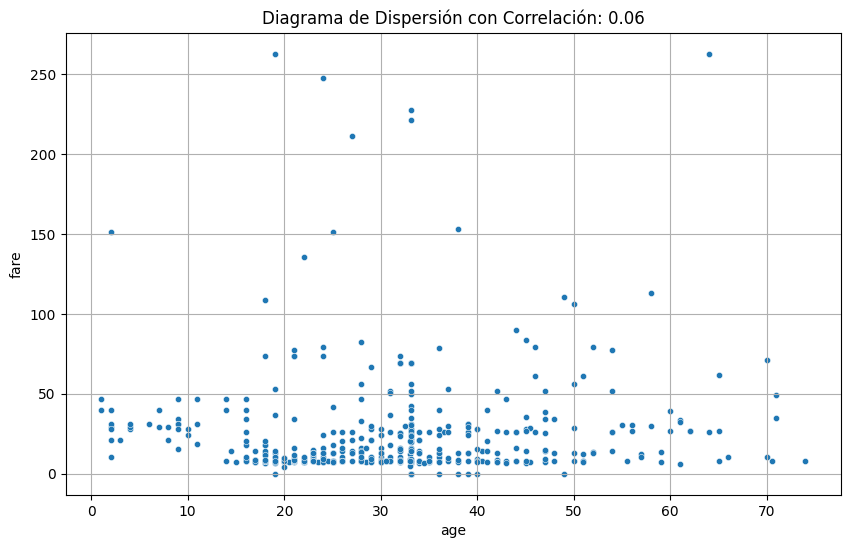

Respuesta yes:


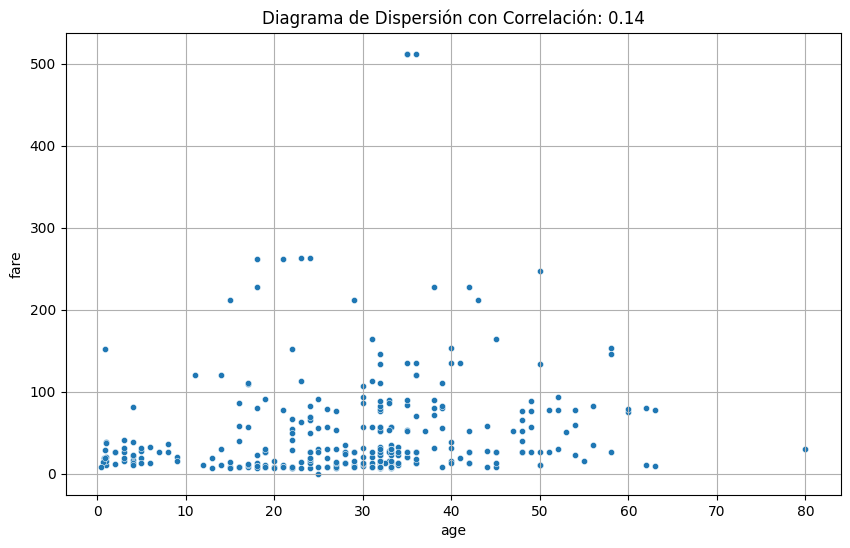

In [86]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

No se aprecia una correlacion entre el precio de billete, edad y supervivencia.
Se aprecia una aglomeracion de edades menores en los supervivientes que en los fallecidos, además de un precio de billete más elevado. 

In [87]:
df_titanic.groupby("alive")[["age", "fare"]].mean()

,age,fare
alive,,
no,31.169144,22.117887
yes,28.954357,48.395408


## #2 Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #2.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

In [88]:
df_viajes = pd.read_csv("../data/dataset_viajes_jun23.csv")

In [96]:
df_viajes

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes
0,Airnar,París,Ginebra,411,Boeing 737,False,1028.691900,51,14232.65,Air_PaGi_10737,Jun23
1,FlyQ,Bali,Roma,12738,Boeing 737,True,33479.132544,1167,468527.19,Fly_BaRo_10737,Jun23
2,TabarAir,Ginebra,Los Angeles,9103,Airbus A380,False,109439.907200,626,584789.19,Tab_GiLo_11380,Jun23
3,MoldaviAir,París,Cincinnati,6370,Boeing 737,False,17027.010000,503,233342.51,Mol_PaCi_10737,Jun23
4,TabarAir,Cincinnati,Roma,7480,Boeing 747,False,86115.744000,518,438535.07,Tab_CiRo_10747,Jun23
...,...,...,...,...,...,...,...,...,...,...,...
595,PamPangea,Bali,Londres,12553,Boeing 737,True,33310.138680,1153,442668.52,Pam_BaLo_10737,Jun23
596,Airnar,Cádiz,París,1447,Airbus A380,False,17229.139600,116,87307.63,Air_CaPa_11380,Jun23
597,Airnar,Los Angeles,Cádiz,9373,Boeing 737,False,23231.917800,731,339943.47,Air_LoCa_10737,Jun23
598,FlyQ,Barcelona,Bali,13058,Boeing 747,True,144766.211200,1070,752212.98,Fly_BaBa_10747,Jun23


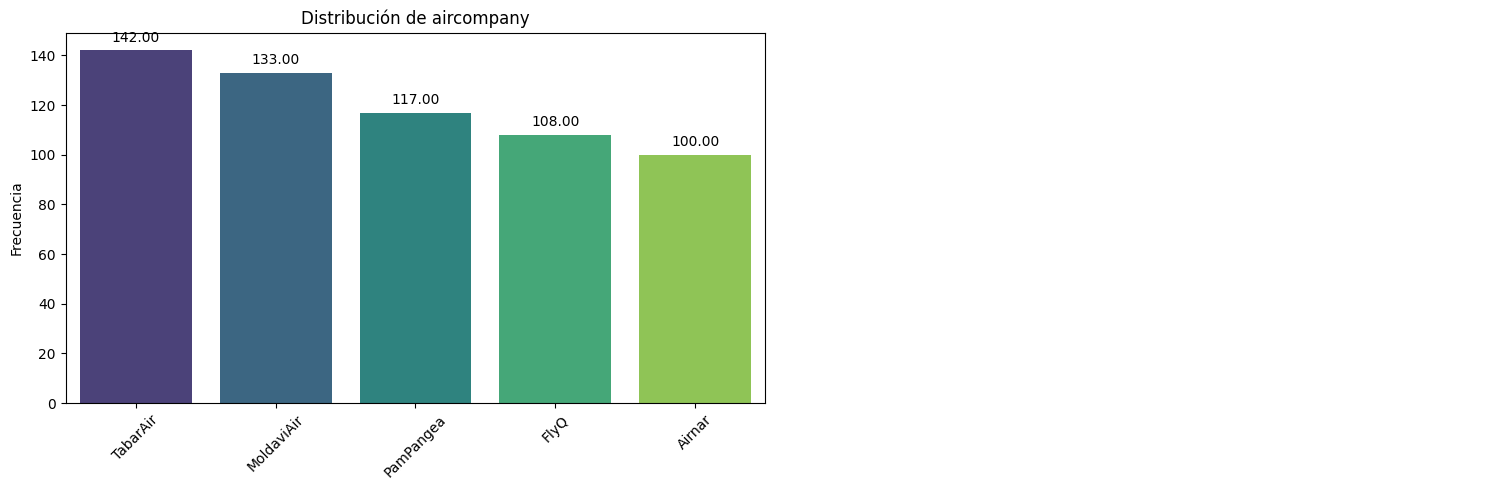

In [97]:
pinta_distribucion_categoricas(df_viajes, ["aircompany"], mostrar_valores=True)

(2,)


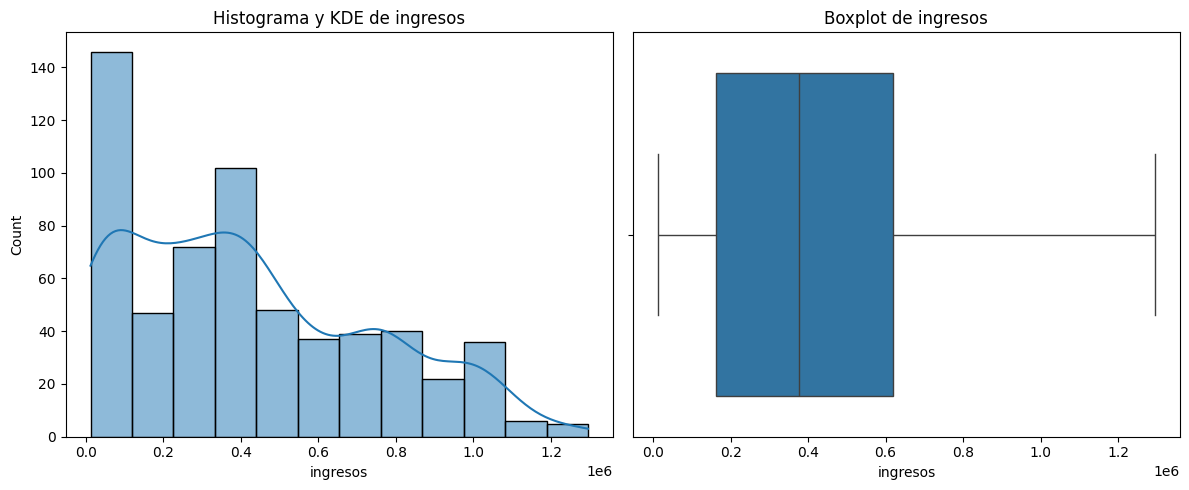

In [91]:
plot_combined_graphs(df_viajes, ["ingresos"])

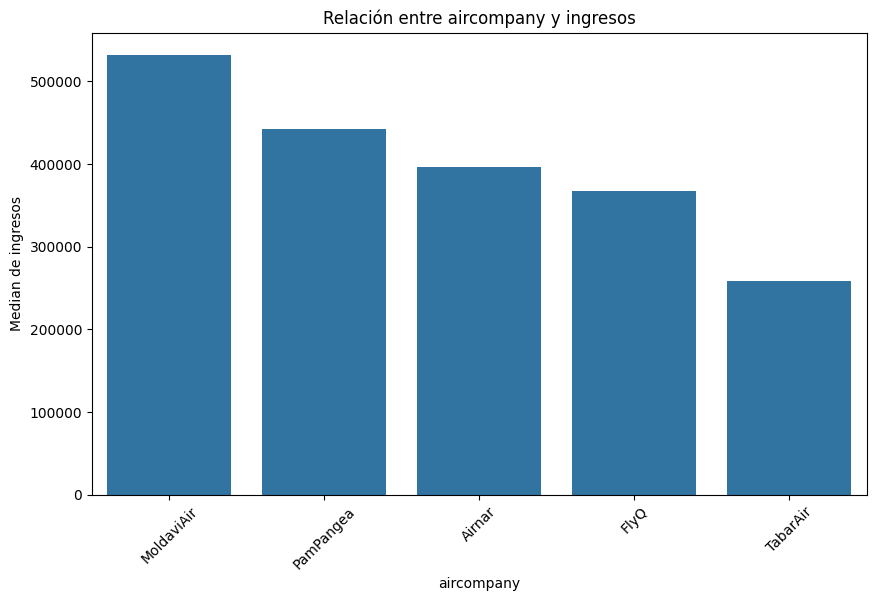

In [93]:
plot_categorical_numerical_relationship(df_viajes, "aircompany", "ingresos", measure= "median")

In [100]:
df_viajes.groupby("aircompany").agg({"ingresos": sum, "destino": len})

,ingresos,destino
aircompany,,
Airnar,40529397.82,100
FlyQ,43374852.87,108
MoldaviAir,72894268.81,133
PamPangea,55974794.70,117
TabarAir,38487996.70,142


In [101]:
df = df_viajes.groupby("aircompany").agg({"ingresos": sum, "destino": len})
(df["ingresos"]/df["destino"]).sort_values(ascending= False)

aircompany
MoldaviAir    548077.209098
PamPangea     478417.048718
Airnar        405293.978200
FlyQ          401619.008056
TabarAir      271042.230282
dtype: float64

Observamos como nuestra compañía es la que menos ingreso en el mes de junio y la que más viajes realizó

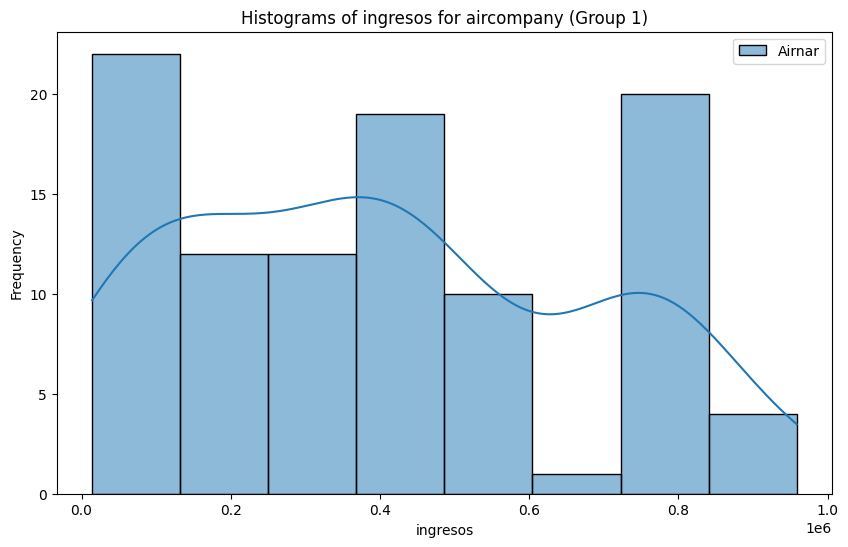

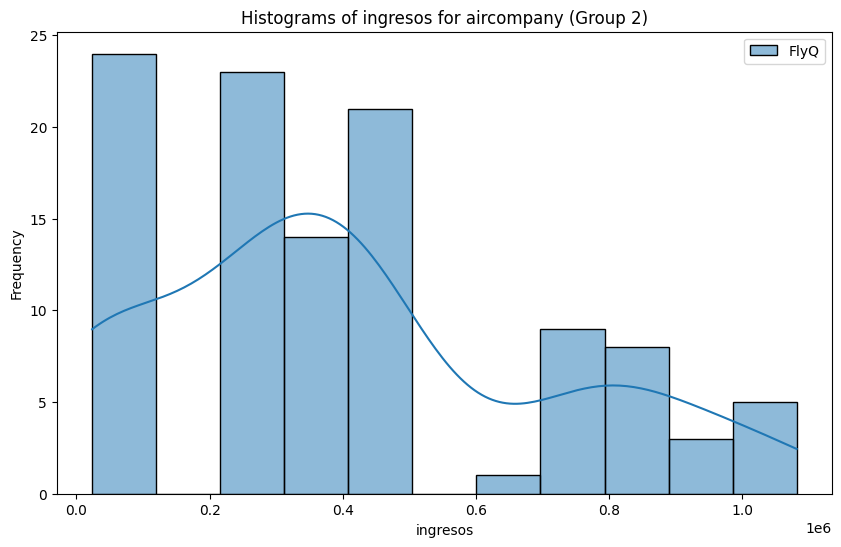

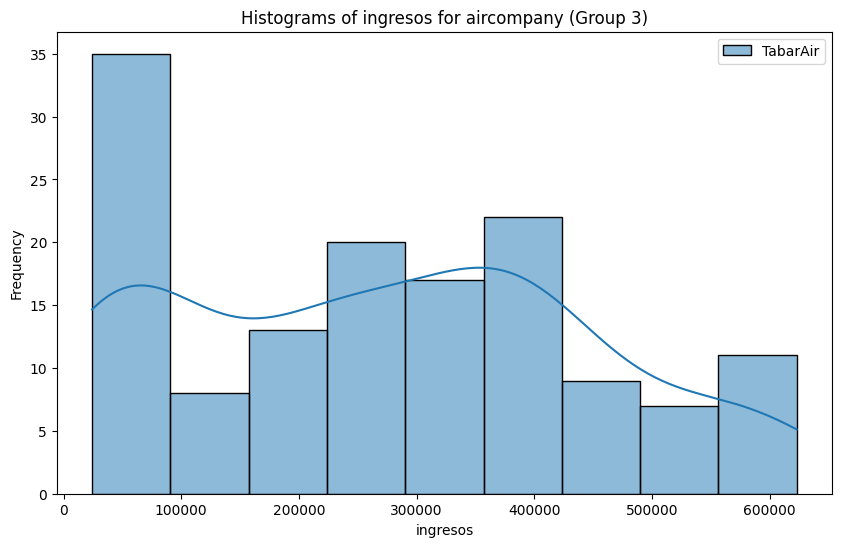

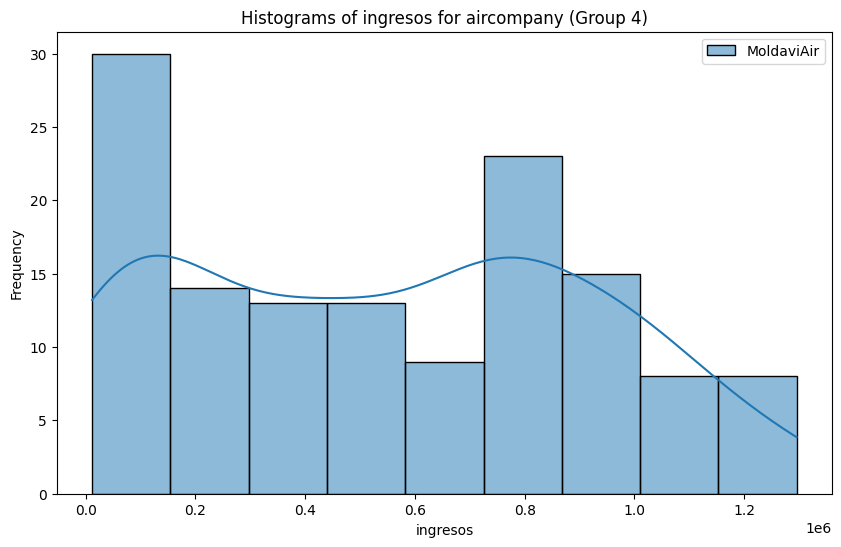

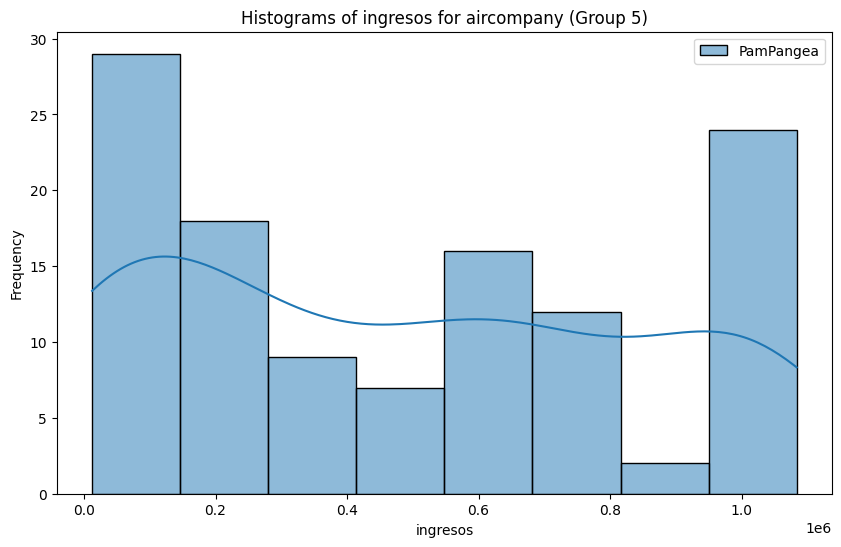

In [ ]:
plot_grouped_histograms(df_viajes,"aircompany", "ingresos", group_size=1)

### #2.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

In [103]:
df_viajes

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes
0,Airnar,París,Ginebra,411,Boeing 737,False,1028.691900,51,14232.65,Air_PaGi_10737,Jun23
1,FlyQ,Bali,Roma,12738,Boeing 737,True,33479.132544,1167,468527.19,Fly_BaRo_10737,Jun23
2,TabarAir,Ginebra,Los Angeles,9103,Airbus A380,False,109439.907200,626,584789.19,Tab_GiLo_11380,Jun23
3,MoldaviAir,París,Cincinnati,6370,Boeing 737,False,17027.010000,503,233342.51,Mol_PaCi_10737,Jun23
4,TabarAir,Cincinnati,Roma,7480,Boeing 747,False,86115.744000,518,438535.07,Tab_CiRo_10747,Jun23
...,...,...,...,...,...,...,...,...,...,...,...
595,PamPangea,Bali,Londres,12553,Boeing 737,True,33310.138680,1153,442668.52,Pam_BaLo_10737,Jun23
596,Airnar,Cádiz,París,1447,Airbus A380,False,17229.139600,116,87307.63,Air_CaPa_11380,Jun23
597,Airnar,Los Angeles,Cádiz,9373,Boeing 737,False,23231.917800,731,339943.47,Air_LoCa_10737,Jun23
598,FlyQ,Barcelona,Bali,13058,Boeing 747,True,144766.211200,1070,752212.98,Fly_BaBa_10747,Jun23


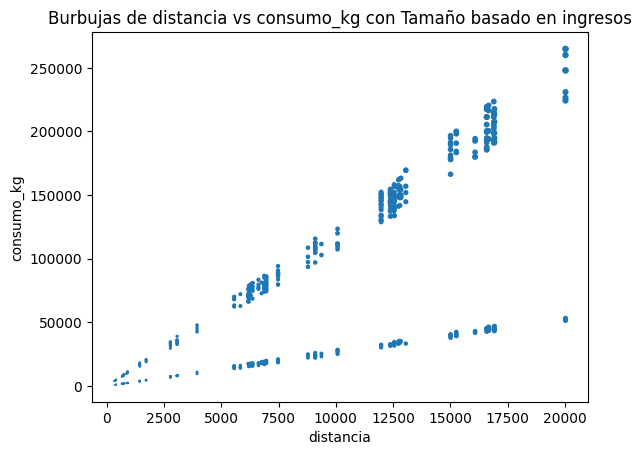

In [104]:
bubble_plot(df_viajes, "distancia", "consumo_kg", "ingresos", scale= 100000)

Observamos que hay una curva diferente al resto comparando ingresos, consumo y distancia. Esta curva es la más eficiente de las 3

### #2.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Realiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

In [105]:
df_viajes["distancia"].describe()

count      600.000000
mean      8071.003333
std       5550.244086
min        344.000000
25%       3073.000000
50%       6877.000000
75%      12553.000000
max      20029.000000
Name: distancia, dtype: float64

In [107]:
bins = [344, 3073, 6877, 12553, 20029]
df_viajes["cat_vuelo"] = pd.cut(df_viajes.distancia, bins=bins, labels= ["cat_1", "cat_2", "cat_3", "cat_4"])

df_viajes

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes,cat_vuelo
0,Airnar,París,Ginebra,411,Boeing 737,False,1028.691900,51,14232.65,Air_PaGi_10737,Jun23,cat_1
1,FlyQ,Bali,Roma,12738,Boeing 737,True,33479.132544,1167,468527.19,Fly_BaRo_10737,Jun23,cat_4
2,TabarAir,Ginebra,Los Angeles,9103,Airbus A380,False,109439.907200,626,584789.19,Tab_GiLo_11380,Jun23,cat_3
3,MoldaviAir,París,Cincinnati,6370,Boeing 737,False,17027.010000,503,233342.51,Mol_PaCi_10737,Jun23,cat_2
4,TabarAir,Cincinnati,Roma,7480,Boeing 747,False,86115.744000,518,438535.07,Tab_CiRo_10747,Jun23,cat_3
...,...,...,...,...,...,...,...,...,...,...,...,...
595,PamPangea,Bali,Londres,12553,Boeing 737,True,33310.138680,1153,442668.52,Pam_BaLo_10737,Jun23,cat_3
596,Airnar,Cádiz,París,1447,Airbus A380,False,17229.139600,116,87307.63,Air_CaPa_11380,Jun23,cat_1
597,Airnar,Los Angeles,Cádiz,9373,Boeing 737,False,23231.917800,731,339943.47,Air_LoCa_10737,Jun23,cat_3
598,FlyQ,Barcelona,Bali,13058,Boeing 747,True,144766.211200,1070,752212.98,Fly_BaBa_10747,Jun23,cat_4


In [108]:
df_viajes["cat_vuelo"].value_counts()

cat_vuelo
cat_3    157
cat_1    155
cat_4    142
cat_2    131
Name: count, dtype: int64

In [109]:
pd.crosstab(df_viajes["aircompany"], df_viajes["cat_vuelo"])

cat_vuelo,cat_1,cat_2,cat_3,cat_4
aircompany,,,,
Airnar,31,12,40,17
FlyQ,24,34,22,28
MoldaviAir,25,19,25,55
PamPangea,27,23,19,42
TabarAir,48,43,51,0


In [110]:
col_directora = "cat_vuelo"
col_1 = "ingresos"
col_2 = "consumo_kg"
dic_multivariante = {}
for valor in df_viajes[col_directora].unique():
    dic_multivariante[valor] = df_viajes.loc[df_viajes[col_directora] == valor, [col_2, col_1]]

Respuesta cat_1


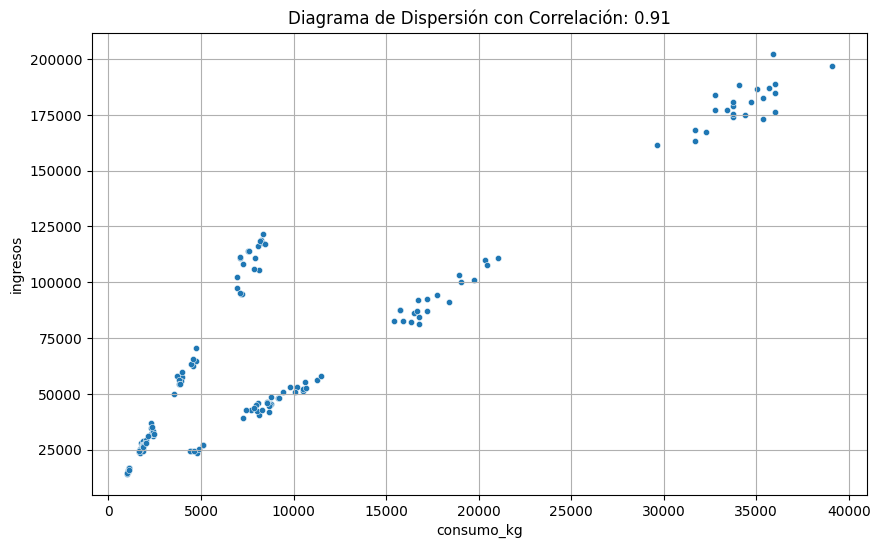

Respuesta cat_4


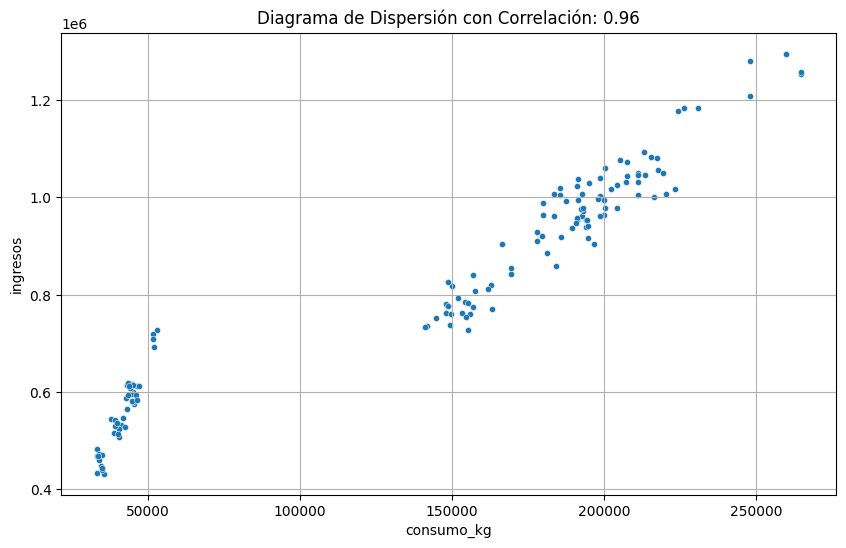

Respuesta cat_3


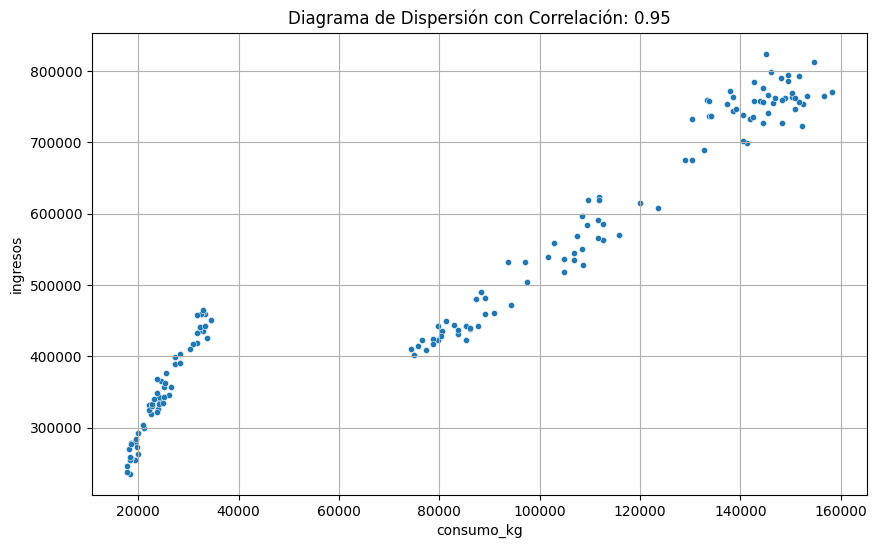

Respuesta cat_2


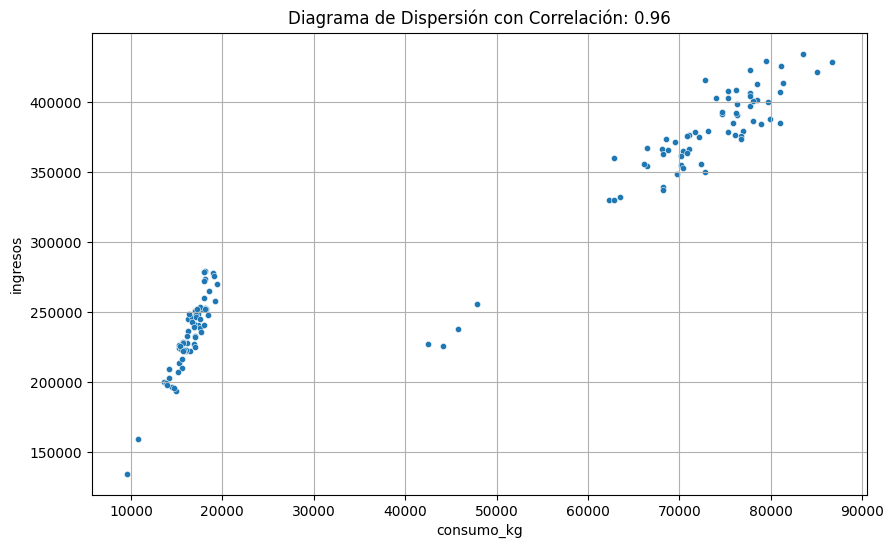

Respuesta nan


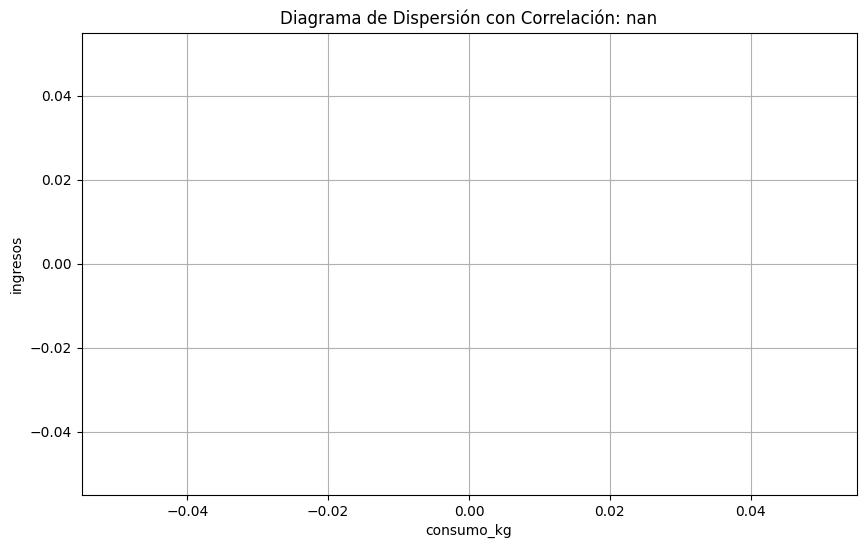

In [111]:
for valor, df_datos in dic_multivariante.items():
    print(f"Respuesta {valor}")
    grafico_dispersion_con_correlacion(df_datos, col_2, col_1, tamano_puntos=20, mostrar_correlacion= True)

Se observa gran diferencia, en todas las categorias de vuelo menos en la 1 (viajes más cortos), entre las curvas con menos consumo y mas ingreso (más pendiente) y el resto.

In [112]:
df_viajes.groupby("cat_vuelo")["ingresos"].mean()

cat_vuelo
cat_1     74444.913419
cat_2    305331.327023
cat_3    524261.032994
cat_4    825074.342394
Name: ingresos, dtype: float64

### Extra:

#1 Consejos para encontrar "objetivos":

Si partes de un dataset que te parece interesante pero sin pregruntras claras, haz como hicimos con el dataset de Aviones. Describe, prioriza a ojo tus variables, realiza un análisis univariante completo, realiza un análisis bivariante ente las parejas de variables que te parecieron más intereantes. Llegados a este punto si el dataset tiene riqueza informativa, algo diferente tiene que haber aparecido (otra cosa es que sea interesante para ti :-)).  

Fíjate en lo que encontramos en el dataset de viajes: la empresa de más vuelos es la que menos ingresos tiene o la existencia clara de una línea de vuelos más eficientes en consumo que otros y otra de mayor ingresos por consumo. Lo siguiente es explorar esos puntos normalmente intentando contestar a: ¿por qué pasa?¿dónde,cuándo o cómo pasa?  

Busca esas "notas discordantes" en tu dataset, ya de por sí son mensajes del análisis. Ordénalas por importancia (importancia = impactan en ingresos, impactan en la calidad de la vida de las personas, impactan en el coste y poco más hay) e intenta entender por qué suceden esas notas discordantes, cómo solucionarlas o aprovecharlas y ya tienes objeetivos para el EDA; incluso si no encuentras respuesta siempre tendras esas notas discordantes, la conclusión de que no se puede avanzar con los datos que se tienen y los próximos pasos de encontrar más información para explicar lo que ocurre.

#2 Contestando a las preguntas de "Viajes".

- Necesitamos identificar esas líneas eficientes, para ello crea una variable que mida el ingreso por kilogramo consumido y otra que mida el kilogramo consumido por kilómetro. Haz el análisis univariante de las mismas intentando encontrar una diferencia clara entre viajes eficientes y no eficientes (que sabemos que existe). Fija un umbral para indicar si un viaje es supereficiente o si no lo es
- Crea esa variable de eficiencia binaria de eficiencia.
- Ahora haz el análisis bivariante de esa eficiencia y las compañías aéreas (queremos ver si realmente eso explica la situación de TabarAir). 
- Para nota: Hacer los análisis multivariante por compañía, eficiencia, tipo de avión y compañía, eficiencia, destino e incluso el de compañía, eficiencia, origen, destino.
- Con todo ello deberías poder encontrar si hay respuesta a la situación de TabarAir además de poder mostrar otros datos interesantes.